
# CSE498R Final Thesis Notebook — Stage 0  
**Topic:** Dataset ZIP Upload → Extract → Auto Mask Generation → Save to Google Drive

This notebook is the **true starting notebook** for your final thesis workflow.

## What this notebook does
1. mounts Google Drive  
2. creates the full project folder structure automatically  
3. lets you upload a dataset ZIP file from your computer  
4. copies that ZIP into Drive  
5. extracts the ZIP  
6. finds all images inside the extracted folder  
7. runs **YOLOv8-seg** to generate masks automatically  
8. keeps only the target class you want  
9. saves:
   - raw images
   - generated masks
   - metadata CSV

## Why this comes before Stage 1
Your Stage 1 preprocessing notebook expects:
- images
- masks

But right now you only have the ZIP and no masks.  
So this notebook prepares the data first.

## Working flow
- Run all cells in order
- Upload the ZIP when the upload cell asks
- Wait until extraction and mask generation finish
- Then run the Stage 1 preprocessing notebook


In [1]:

# ============================================================
# CELL 1: Install required packages
# ============================================================

%%capture
!pip -q install ultralytics opencv-python pillow tqdm pandas matplotlib

print("Packages installed successfully.")


In [2]:

# ============================================================
# CELL 2: Mount Google Drive and create project structure
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os

PROJECT_ROOT = Path("/content/drive/MyDrive/CSE498R_Final_Thesis")
DATA_ROOT = PROJECT_ROOT / "data"

SOURCE_ZIP_ROOT = DATA_ROOT / "source_zips"
EXTRACT_ROOT = DATA_ROOT / "extracted"
RAW_ROOT = DATA_ROOT / "raw"
RAW_IMAGE_ROOT = RAW_ROOT / "images"
RAW_MASK_ROOT = RAW_ROOT / "masks"
RAW_META_ROOT = RAW_ROOT / "metadata"

PROCESSED_ROOT = DATA_ROOT / "processed"
SPLIT_ROOT = DATA_ROOT / "splits"
VIS_ROOT = PROJECT_ROOT / "visualizations"
MODEL_ROOT = PROJECT_ROOT / "models"
RESULT_ROOT = PROJECT_ROOT / "results"

for p in [
    PROJECT_ROOT, DATA_ROOT, SOURCE_ZIP_ROOT, EXTRACT_ROOT,
    RAW_ROOT, RAW_IMAGE_ROOT, RAW_MASK_ROOT, RAW_META_ROOT,
    PROCESSED_ROOT, SPLIT_ROOT, VIS_ROOT, MODEL_ROOT, RESULT_ROOT
]:
    p.mkdir(parents=True, exist_ok=True)

print("Project folder structure created successfully.")
print("PROJECT_ROOT =", PROJECT_ROOT)
print("Upload ZIPs will be saved inside:", SOURCE_ZIP_ROOT)


Mounted at /content/drive
Project folder structure created successfully.
PROJECT_ROOT = /content/drive/MyDrive/CSE498R_Final_Thesis
Upload ZIPs will be saved inside: /content/drive/MyDrive/CSE498R_Final_Thesis/data/source_zips



## Folder structure created by code

```text
MyDrive/
 └── CSE498R_Final_Thesis/
      ├── data/
      │    ├── source_zips/
      │    ├── extracted/
      │    ├── raw/
      │    │    ├── images/
      │    │    ├── masks/
      │    │    └── metadata/
      │    ├── processed/
      │    └── splits/
      ├── models/
      ├── results/
      └── visualizations/
```

So you do **not** need to create anything manually in Drive.


In [3]:

# ============================================================
# CELL 3: Upload dataset ZIP from your computer
# ============================================================
# This cell opens a file picker in Colab.
# Please upload your dataset ZIP here, for example:
# coco_200_persons.zip

from google.colab import files
import shutil
from pathlib import Path

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No ZIP file was uploaded.")

uploaded_name = list(uploaded.keys())[0]
uploaded_local_path = Path("/content") / uploaded_name
drive_zip_path = SOURCE_ZIP_ROOT / uploaded_name

shutil.copy2(uploaded_local_path, drive_zip_path)

print("Uploaded ZIP copied to Google Drive:")
print(drive_zip_path)


Saving coco_200_persons.zip to coco_200_persons.zip
Uploaded ZIP copied to Google Drive:
/content/drive/MyDrive/CSE498R_Final_Thesis/data/source_zips/coco_200_persons.zip


In [4]:

# ============================================================
# CELL 4: Extract uploaded ZIP into Drive
# ============================================================

import zipfile
import shutil

zip_name = uploaded_name
zip_path = SOURCE_ZIP_ROOT / zip_name

extract_dir = EXTRACT_ROOT / Path(zip_name).stem

# If the folder already exists from an earlier run, clear it first
if extract_dir.exists():
    shutil.rmtree(extract_dir)
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

print("ZIP extracted successfully.")
print("Extracted to:", extract_dir)


ZIP extracted successfully.
Extracted to: /content/drive/MyDrive/CSE498R_Final_Thesis/data/extracted/coco_200_persons


In [5]:

# ============================================================
# CELL 5: Find all images inside extracted dataset
# ============================================================

from pathlib import Path

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def find_all_images(root_dir):
    root_dir = Path(root_dir)
    image_paths = []
    for p in root_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            image_paths.append(p)
    return sorted(image_paths)

all_images = find_all_images(extract_dir)

print("Total images found inside extracted ZIP:", len(all_images))
if len(all_images) > 0:
    print("Example images:")
    for x in all_images[:10]:
        print(" -", x)
else:
    raise ValueError("No images found after extraction. Please check your ZIP contents.")


Total images found inside extracted ZIP: 200
Example images:
 - /content/drive/MyDrive/CSE498R_Final_Thesis/data/extracted/coco_200_persons/000000001000.jpg
 - /content/drive/MyDrive/CSE498R_Final_Thesis/data/extracted/coco_200_persons/000000002685.jpg
 - /content/drive/MyDrive/CSE498R_Final_Thesis/data/extracted/coco_200_persons/000000004134.jpg
 - /content/drive/MyDrive/CSE498R_Final_Thesis/data/extracted/coco_200_persons/000000005001.jpg
 - /content/drive/MyDrive/CSE498R_Final_Thesis/data/extracted/coco_200_persons/000000005193.jpg
 - /content/drive/MyDrive/CSE498R_Final_Thesis/data/extracted/coco_200_persons/000000006771.jpg
 - /content/drive/MyDrive/CSE498R_Final_Thesis/data/extracted/coco_200_persons/000000006954.jpg
 - /content/drive/MyDrive/CSE498R_Final_Thesis/data/extracted/coco_200_persons/000000009400.jpg
 - /content/drive/MyDrive/CSE498R_Final_Thesis/data/extracted/coco_200_persons/000000009590.jpg
 - /content/drive/MyDrive/CSE498R_Final_Thesis/data/extracted/coco_200_pers

In [6]:

# ============================================================
# CELL 6: Configuration for automatic mask generation
# ============================================================
# You can change target_class_name if needed later.
# For your thesis, 'person' is the best first target.

CFG = {
    "target_class_name": "person",
    "model_name": "yolov8x-seg.pt",
    "conf_threshold": 0.25,
    "imgsz": 1024,
    "max_images": None,   # Example: set 100 for quick test, or keep None for all images
    "save_preview_count": 8
}

print(CFG)


{'target_class_name': 'person', 'model_name': 'yolov8x-seg.pt', 'conf_threshold': 0.25, 'imgsz': 1024, 'max_images': None, 'save_preview_count': 8}


In [7]:

# ============================================================
# CELL 7: Load YOLOv8-seg model
# ============================================================

from ultralytics import YOLO

model = YOLO(CFG["model_name"])
print("YOLO model loaded:", CFG["model_name"])
print("Model classes:", model.names)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO model loaded: yolov8x-seg.pt
Model classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: '

In [8]:

# ============================================================
# CELL 8: Find the class ID for the chosen target class
# ============================================================

target_class_name = CFG["target_class_name"].strip().lower()

target_class_id = None
for k, v in model.names.items():
    if str(v).lower() == target_class_name:
        target_class_id = int(k)
        break

if target_class_id is None:
    raise ValueError(f"Target class '{target_class_name}' not found in model classes.")

print("Target class:", target_class_name)
print("Target class ID:", target_class_id)


Target class: person
Target class ID: 0


In [9]:

# ============================================================
# CELL 9: Helper functions for mask generation
# ============================================================

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import shutil

def safe_stem_with_index(idx, path_obj):
    return f"{idx:06d}_{path_obj.stem}"

def save_rgb_image(src_path, dst_path):
    img = Image.open(src_path).convert("RGB")
    img.save(dst_path)

def combine_person_masks(result, target_class_id):
    '''
    Combine all masks of the target class into one binary mask.
    Returns:
        combined_mask_uint8 or None
        num_instances
        max_conf
    '''
    if result.masks is None:
        return None, 0, 0.0

    if result.boxes is None or len(result.boxes) == 0:
        return None, 0, 0.0

    classes = result.boxes.cls.detach().cpu().numpy().astype(int)
    confs = result.boxes.conf.detach().cpu().numpy().astype(float)
    masks = result.masks.data.detach().cpu().numpy()

    selected = []
    selected_confs = []

    for i in range(len(classes)):
        if classes[i] == target_class_id and confs[i] >= CFG["conf_threshold"]:
            selected.append(masks[i])
            selected_confs.append(confs[i])

    if len(selected) == 0:
        return None, 0, 0.0

    combined = np.zeros_like(selected[0], dtype=np.uint8)
    for m in selected:
        combined = np.maximum(combined, (m > 0.5).astype(np.uint8))

    combined = combined * 255
    return combined, len(selected), float(max(selected_confs))

def overlay_mask_on_image(image_rgb, mask_gray):
    overlay = image_rgb.copy()
    overlay[mask_gray > 0] = [255, 0, 0]
    return overlay


In [10]:

# ============================================================
# CELL 10: Generate masks and save images + masks to Drive
# ============================================================

records = []

images_to_process = all_images
if CFG["max_images"] is not None:
    images_to_process = all_images[:CFG["max_images"]]

print("Images to process:", len(images_to_process))

for idx, img_path in enumerate(tqdm(images_to_process, desc="Generating masks")):
    stem = safe_stem_with_index(idx, img_path)

    try:
        results = model.predict(
            source=str(img_path),
            conf=CFG["conf_threshold"],
            imgsz=CFG["imgsz"],
            verbose=False
        )
        result = results[0]

        mask, num_instances, max_conf = combine_person_masks(result, target_class_id)

        if mask is None:
            continue

        raw_img_save_path = RAW_IMAGE_ROOT / f"{stem}.png"
        raw_mask_save_path = RAW_MASK_ROOT / f"{stem}.png"

        # Save RGB image
        image_rgb = np.array(Image.open(img_path).convert("RGB"))
        Image.fromarray(image_rgb).save(raw_img_save_path)

        # Resize predicted mask to original image size if needed
        if mask.shape[:2] != image_rgb.shape[:2]:
            mask = cv2.resize(mask, (image_rgb.shape[1], image_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)

        Image.fromarray(mask).save(raw_mask_save_path)

        h, w = mask.shape[:2]
        mask_ratio = float((mask > 0).sum()) / float(h * w)

        records.append({
            "id": stem,
            "source_image_path": str(img_path),
            "raw_image_path": str(raw_img_save_path),
            "raw_mask_path": str(raw_mask_save_path),
            "height": h,
            "width": w,
            "num_target_instances": num_instances,
            "max_conf": max_conf,
            "mask_ratio": mask_ratio
        })

    except Exception as e:
        print(f"Error on {img_path}: {e}")

meta_df = pd.DataFrame(records)
meta_csv_path = RAW_META_ROOT / "stage0_generated_metadata.csv"
meta_df.to_csv(meta_csv_path, index=False)

print("Mask generation complete.")
print("Kept samples with target masks:", len(meta_df))
print("Metadata saved to:", meta_csv_path)
display(meta_df.head())


Images to process: 200


Generating masks:   0%|          | 0/200 [00:00<?, ?it/s]

Mask generation complete.
Kept samples with target masks: 200
Metadata saved to: /content/drive/MyDrive/CSE498R_Final_Thesis/data/raw/metadata/stage0_generated_metadata.csv


,id,source_image_path,raw_image_path,raw_mask_path,height,width,num_target_instances,max_conf,mask_ratio
0,000000_000000001000,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,480,640,12,0.944424,0.409352
1,000001_000000002685,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,555,640,7,0.956817,0.372047
2,000002_000000004134,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,425,640,12,0.937902,0.552055
3,000003_000000005001,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,480,640,19,0.892137,0.535286
4,000004_000000005193,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,425,640,6,0.948362,0.363864


In [11]:

# ============================================================
# CELL 11: Quick quality summary
# ============================================================

if len(meta_df) == 0:
    raise ValueError("No masks were generated. Try lowering confidence threshold or checking the dataset.")

print("Summary statistics:")
display(meta_df[["num_target_instances", "max_conf", "mask_ratio"]].describe())

print("\nFew strongest samples by confidence:")
display(meta_df.sort_values("max_conf", ascending=False).head(10))


Summary statistics:


,num_target_instances,max_conf,mask_ratio
count,200.000000,200.000000,200.000000
mean,9.305000,0.922029,0.358952
std,4.656219,0.045865,0.146644
min,4.000000,0.628147,0.073869
25%,6.000000,0.914358,0.240554
50%,9.000000,0.932052,0.341129
75%,11.000000,0.945508,0.461618
max,28.000000,0.969065,0.801312



Few strongest samples by confidence:


,id,source_image_path,raw_image_path,raw_mask_path,height,width,num_target_instances,max_conf,mask_ratio
23,000023_000000060932,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,428,640,10,0.969065,0.399558
16,000016_000000032334,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,480,640,6,0.965165,0.611273
56,000056_000000160864,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,389,640,6,0.965141,0.284704
67,000067_000000180101,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,480,640,4,0.964600,0.247725
197,000197_000000567640,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,425,640,10,0.964561,0.297022
157,000157_000000453166,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,425,640,4,0.963023,0.567614
141,000141_000000401862,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,480,640,7,0.962173,0.265192
98,000098_000000277020,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,360,640,5,0.960944,0.611714
109,000109_000000294350,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,425,640,9,0.959183,0.359246
138,000138_000000397354,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,480,640,7,0.959069,0.255667


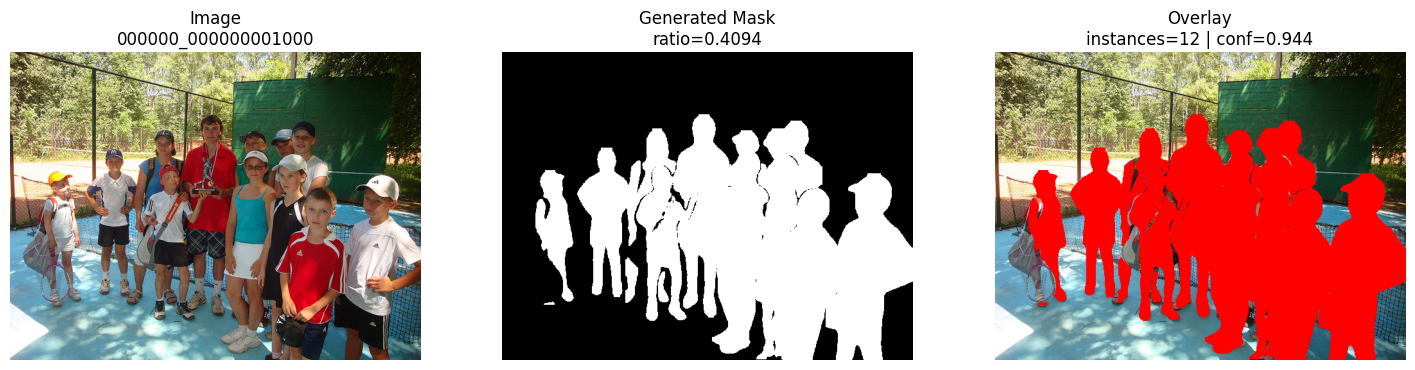

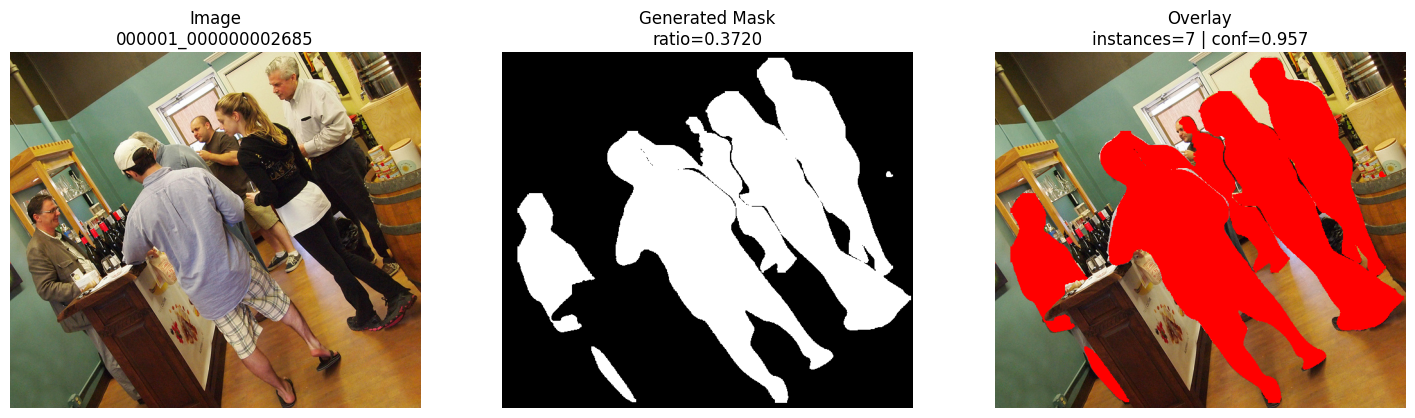

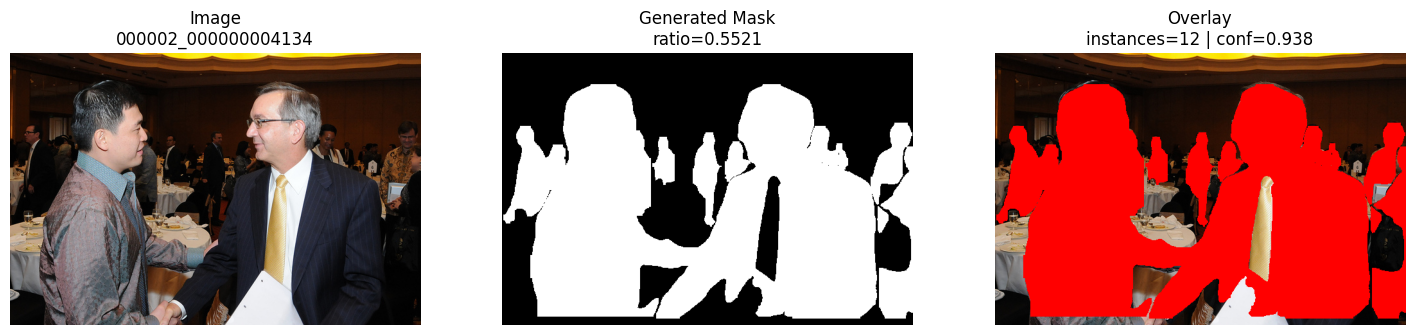

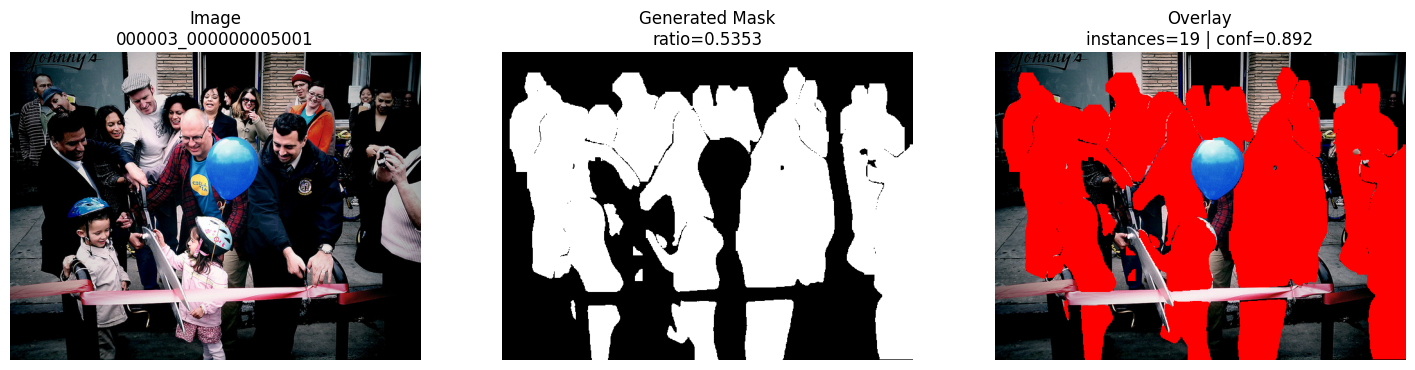

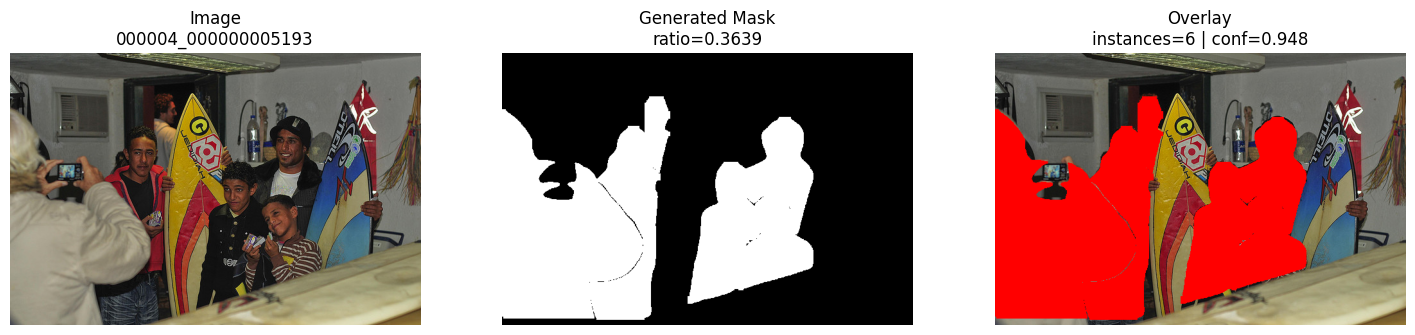

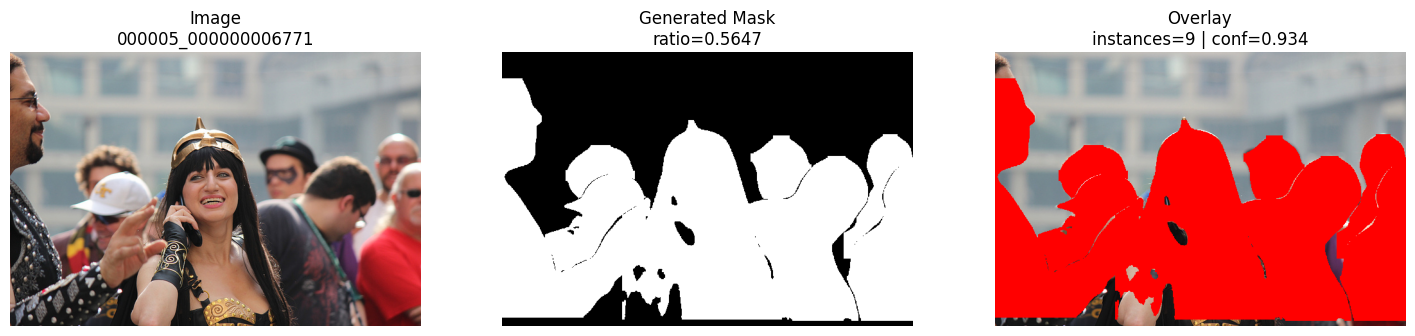

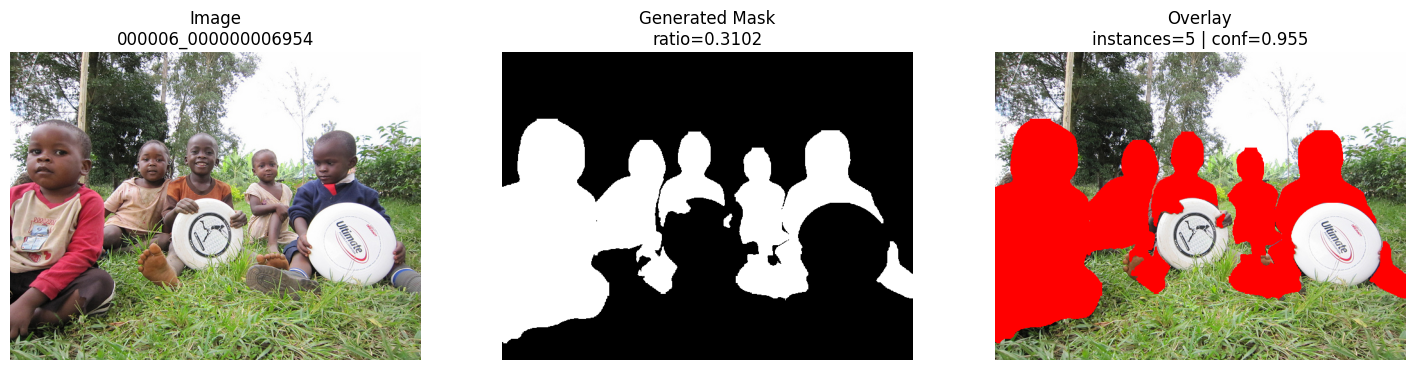

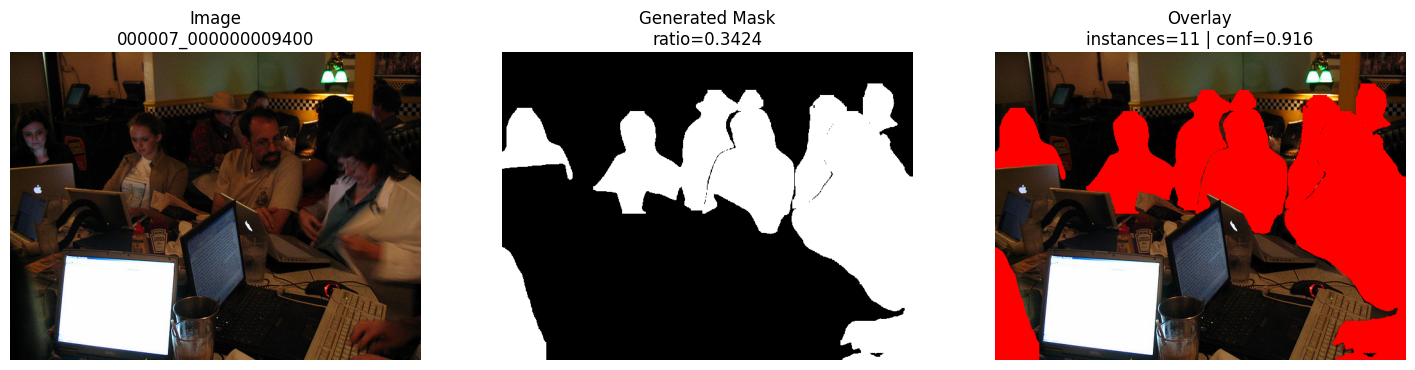

In [12]:

# ============================================================
# CELL 12: Visual preview of generated masks
# ============================================================

preview_df = meta_df.head(CFG["save_preview_count"]).copy()

for _, row in preview_df.iterrows():
    image_rgb = np.array(Image.open(row["raw_image_path"]).convert("RGB"))
    mask_gray = np.array(Image.open(row["raw_mask_path"]).convert("L"))
    overlay = overlay_mask_on_image(image_rgb, mask_gray)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title(f"Image\n{row['id']}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_gray, cmap="gray")
    plt.title(f"Generated Mask\nratio={row['mask_ratio']:.4f}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\ninstances={row['num_target_instances']} | conf={row['max_conf']:.3f}")
    plt.axis("off")

    plt.show()



# What to do after Stage 0

After this notebook finishes successfully, your Drive will contain:

- `data/raw/images/`
- `data/raw/masks/`
- `data/raw/metadata/stage0_generated_metadata.csv`

Then you should run the **Stage 1 preprocessing notebook**:
- proper resizing
- mask cleaning
- adaptive context ring creation
- filtering
- train/val/test split

So this notebook prepares the raw dataset, and the next notebook prepares the research-ready dataset.
